<a href="https://colab.research.google.com/github/vadapallimaneesha/machine_learning-/blob/main/Week8portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q pyspark

# 1. Set up the environment

This cell installs the `pyspark` library, which is necessary for working with Apache Spark in Python. The `-q` flag ensures a quiet installation without excessive output.

In [4]:
# ==========================================================
# 2. Import required libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan
from pyspark.ml.feature import VectorAssembler, StandardScaler

from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


This cell is responsible for initializing a **SparkSession**, which is the entry point for all Spark functionality. Think of it as your main connection to the Spark engine.

Here's a breakdown of what the code does:

*   **`SparkSession.builder`**: This provides a builder interface to create and configure a `SparkSession` instance. It allows you to set various options before creating the session.
*   **`.appName("Perceptron_MSc_Assessed_Lab")`**: This method sets a human-readable name for your Spark application. This name will appear in the Spark UI, making it easier to identify your application when you have multiple Spark jobs running.
*   **`.getOrCreate()`**: This is a crucial method. It attempts to get an existing `SparkSession` if one has already been created with the same configuration. If no such session exists, it creates a new one. This prevents you from inadvertently creating multiple Spark sessions within the same application, which can lead to resource conflicts and unexpected behavior.

Finally, **`print("Spark version:", spark.version)`** simply outputs the version of Spark that is being used, which is useful for verification and debugging.

This cell sets up the Spark processing environment. Here's what each part does:

*   **`SparkSession.builder`**: Initiates the process of building a SparkSession.
*   **`.appName("Perceptron_MSc_Assessed_Lab")`**: Assigns a name to your Spark application for easy identification in the Spark UI.
*   **`.getOrCreate()`**: Retrieves an existing SparkSession or creates a new one if it doesn't exist, preventing duplicate sessions.
*   **`print("Spark version:", spark.version)`**: Displays the version of Spark in use for verification.

In [5]:

# 3. Create a Spark session

spark = (
    SparkSession.builder
    .appName("Perceptron_MSc_Assessed_Lab")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.3


# 3.1. Mount Google Drive

This step connects your Google Colab environment to your Google Drive, allowing the notebook to access files stored there. You will be prompted to grant authorization.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell loads the dataset from the specified CSV file into a Spark DataFrame. `inferSchema=True` automatically detects column data types, and `header=True` indicates that the first row contains column names. `df.head()` displays the first row to give a quick preview of the data.

In [8]:
# 4. Load the dataset
df = spark.read.csv('/content/BankNote_Authentication.csv',inferSchema=True, header =True)
df.head()

Row(variance=3.6216, skewness=8.6661, curtosis=-2.8073, entropy=-0.44699, class=0)

This cell inspects the loaded dataset to understand its structure and content.

*   **`df.printSchema()`**: Displays the schema (column names and their data types).
*   **`df.count()` and `len(df.columns)`**: Calculate and print the number of rows and columns.
*   **`df.describe().show()`**: Provides descriptive statistics for numerical columns (count, mean, stddev, min, max).
*   **`df.groupBy('Class').count().orderBy('Class').show()`**: Shows the distribution of observations across different classes.
*   **`df.select(...)`**: Checks for and counts any missing values (`null` or `NaN`) in each column.

In [9]:
# ==========================================================
# 5. Inspect the dataset
# ==========================================================

print("Schema")
df.printSchema()

row_count = df.count()
column_count = len(df.columns)

print("\nDimensions")
print("Rows   :", row_count)
print("Columns:", column_count)

print("\nSummary statistics")
df.describe().show()

print("\nClass distribution")
df.groupBy("Class").count().orderBy("Class").show()

print("\nMissing values")
df.select([
    count(
        when(col(c).isNull() | isnan(c), c)
    ).alias(c)
    for c in df.columns
]).show()

Schema
root
 |-- variance: double (nullable = true)
 |-- skewness: double (nullable = true)
 |-- curtosis: double (nullable = true)
 |-- entropy: double (nullable = true)
 |-- class: integer (nullable = true)


Dimensions
Rows   : 1372
Columns: 5

Summary statistics
+-------+------------------+------------------+------------------+------------------+------------------+
|summary|          variance|          skewness|          curtosis|           entropy|             class|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|              1372|              1372|              1372|              1372|              1372|
|   mean|0.4337352570699707|1.9223531206393603|1.3976271172667651|-1.191656520043731|0.4446064139941691|
| stddev|2.8427625862785577| 5.869046743695513| 4.310030090106595| 2.101013137359609|0.4971032701256608|
|    min|           -7.0421|          -13.7731|           -5.2861|           -8.5482|                 0

This cell visualizes the distribution of the target variable, 'Class'. It converts the Spark DataFrame to a Pandas DataFrame for easier plotting, counts the occurrences of each class, and then displays them using a bar chart. The `print(class_counts)` statement also shows the exact counts.

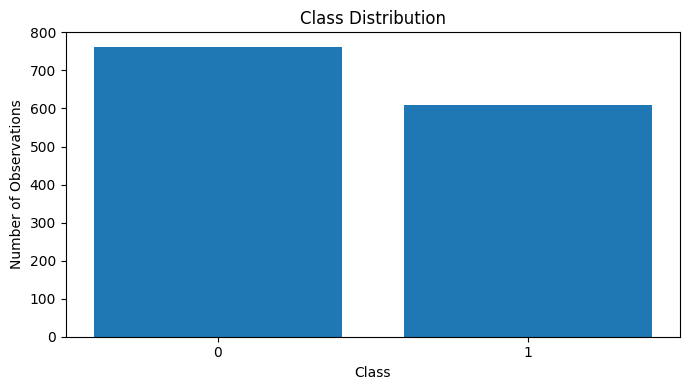

class
0    762
1    610
Name: count, dtype: int64


In [10]:
# ==========================================================
# 6. Visual 1: Class distribution
# ==========================================================

# Convert Spark DataFrame to Pandas DataFrame for visualization
pdf = df.toPandas()

class_counts = pdf["class"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

print(class_counts)

This section generates histograms for each feature (`variance`, `skewness`, `curtosis`, `entropy`), showing their distribution. Importantly, these histograms are segmented by class, allowing for a visual comparison of how each feature's values differ between the two classes. This helps in understanding the separability of the classes based on individual features.

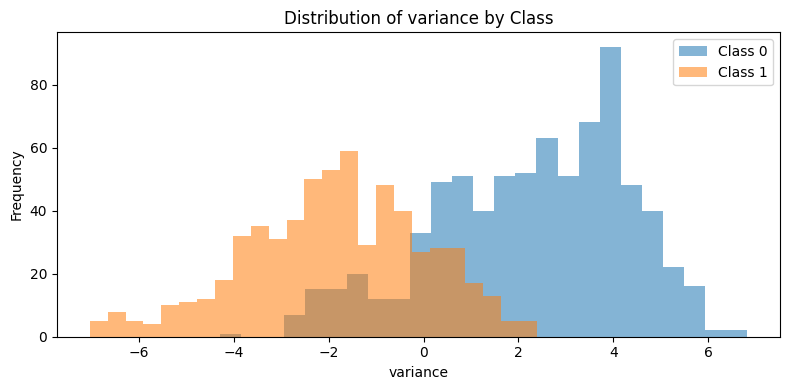

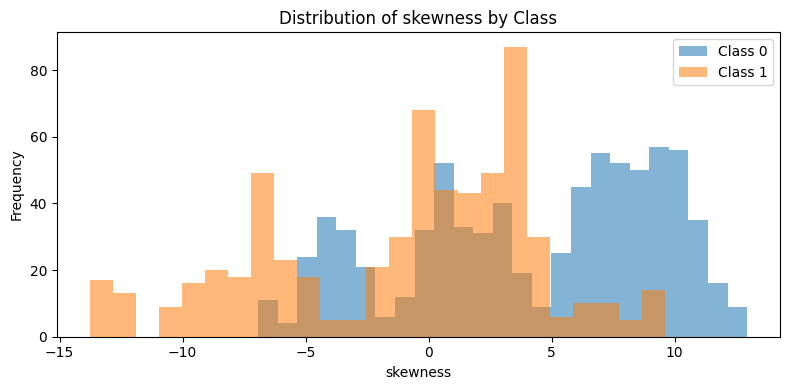

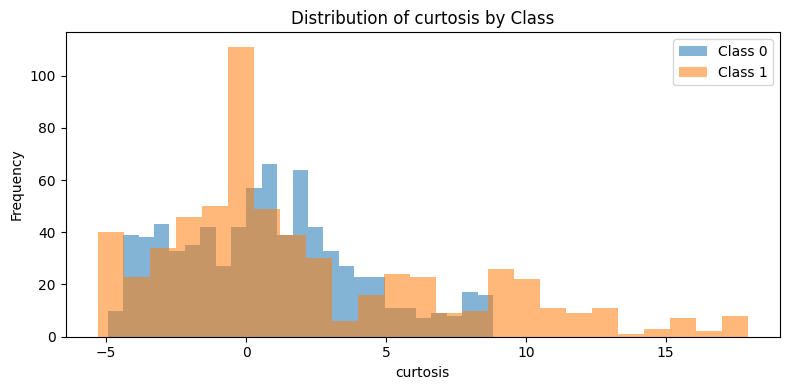

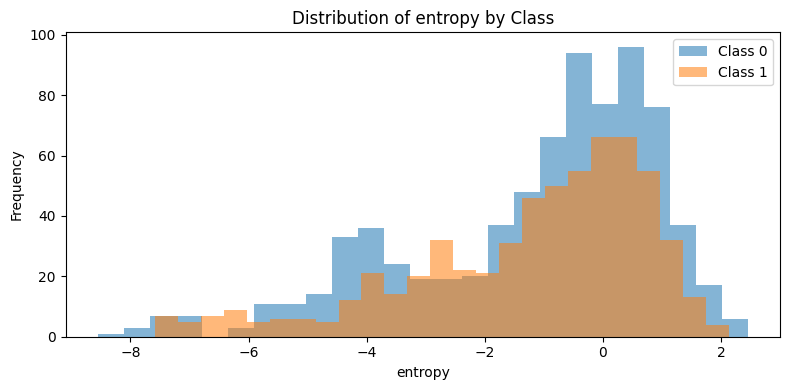

In [11]:
# ==========================================================
# 7. Visuals 2–5: Feature distributions by class
# ==========================================================
# A separate figure is produced for each feature.

feature_columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
]

for feature in feature_columns:
    plt.figure(figsize=(8, 4))

    for class_value in sorted(pdf["class"].unique()):
        values = pdf.loc[pdf["class"] == class_value, feature]
        plt.hist(
            values,
            bins=25,
            alpha=0.55,
            label=f"Class {class_value}",
        )

    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

This cell computes and visualizes the correlation matrix between the specified features. The `imshow` function creates a heatmap, where the color intensity represents the correlation coefficient between pairs of features. The actual correlation values are annotated on the heatmap for precise interpretation. This helps identify linear relationships and potential multicollinearity among features.

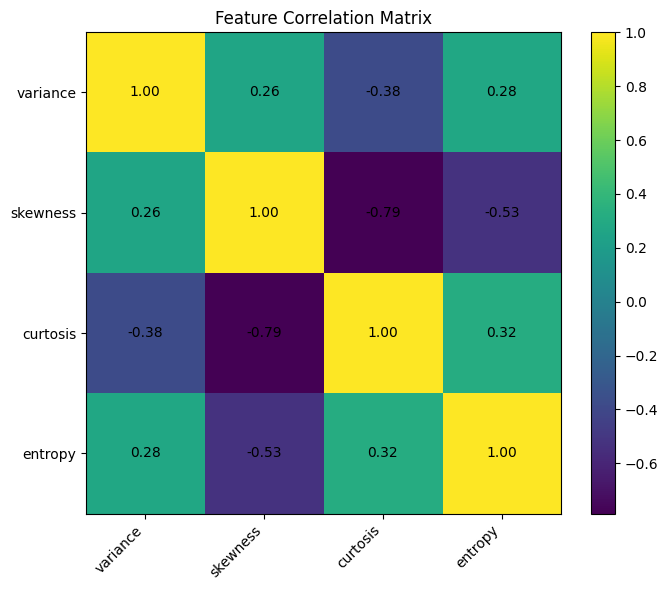

In [12]:
# ==========================================================
# 9. Visual 7: Correlation matrix
# ==========================================================

correlation_matrix = pdf[feature_columns].corr()

plt.figure(figsize=(7, 6))
image = plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(image)

tick_positions = np.arange(len(feature_columns))
plt.xticks(tick_positions, feature_columns, rotation=45, ha="right")
plt.yticks(tick_positions, feature_columns)

for row in range(correlation_matrix.shape[0]):
    for column in range(correlation_matrix.shape[1]):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

This cell uses Spark's `VectorAssembler` to combine the individual feature columns (`variance`, `skewness`, `curtosis`, `entropy`) into a single vector-valued column named `features`. This vector format is required by many PySpark ML algorithms. It then displays the first few rows of the assembled data, showing the new `features` column alongside the `Class` label.

In [13]:
# ==========================================================
# 10. Assemble the raw feature vector
# ==========================================================

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
)

assembled_data = assembler.transform(df)

assembled_data.select("features", "Class").show(5, truncate=False)

+--------------------------------+-----+
|features                        |Class|
+--------------------------------+-----+
|[3.6216,8.6661,-2.8073,-0.44699]|0    |
|[4.5459,8.1674,-2.4586,-1.4621] |0    |
|[3.866,-2.6383,1.9242,0.10645]  |0    |
|[3.4566,9.5228,-4.0112,-3.5944] |0    |
|[0.32924,-4.4552,4.5718,-0.9888]|0    |
+--------------------------------+-----+
only showing top 5 rows


This step splits the assembled dataset into training and test sets using an 80/20 ratio. It's crucial to split the data *before* fitting any scalers or models to prevent data leakage. The `seed` parameter ensures reproducibility of the split. The `cache()` method is used to store the DataFrames in memory, which speeds up repeated access. Finally, it prints the number of observations in each split.

In [14]:
# ==========================================================
# 11. Split BEFORE fitting the scaler
# ==========================================================

train_raw, test_raw = assembled_data.randomSplit(
    [0.80, 0.20],
    seed=RANDOM_STATE,
)

# Cache because these frames are used repeatedly.
train_raw = train_raw.cache()
test_raw = test_raw.cache()

train_count = train_raw.count()
test_count = test_raw.count()

print("Training observations:", train_count)
print("Test observations    :", test_count)
print("Total                :", train_count + test_count)

Training observations: 1137
Test observations    : 235
Total                : 1372


This cell applies standardization (mean removal and scaling to unit variance) to the feature vectors. It initializes a `StandardScaler` to operate on the `features` column and output `scaledFeatures`. Crucially, the scaler is `fit` *only* on the `train_raw` data to avoid data leakage from the test set. The fitted scaler model then transforms both the training and test sets. It then shows the first few scaled feature vectors from the training data.

In [15]:
# ==========================================================
# 12. Fit the scaler only on the training data
# ==========================================================

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True,
)

scaler_model = scaler.fit(train_raw)

train_df = scaler_model.transform(train_raw)
test_df = scaler_model.transform(test_raw)

print("Training data after scaling")
train_df.select("scaledFeatures", "Class").show(5, truncate=False)

Training data after scaling
+---------------------------------------------------------------------------------+-----+
|scaledFeatures                                                                   |Class|
+---------------------------------------------------------------------------------+-----+
|[-2.6184051920411533,1.2629642893582487,-0.2688474035489203,-1.6748889907518456] |1    |
|[-2.6163990611526287,1.2790698696791887,-0.2909452624848473,-1.6061699070175373] |1    |
|[-2.5165148600713416,1.1967428484682834,-0.34487620051090234,-1.2163470267252838]|1    |
|[-2.511622716325641,0.8802880892728453,-0.16970399532369912,-3.0653019280083433] |1    |
|[-2.480756456865356,0.8466410927913974,-0.16787966196470996,-3.0653019280083433] |1    |
+---------------------------------------------------------------------------------+-----+
only showing top 5 rows


This cell prints the mean and standard deviation learned by the `StandardScaler` for each feature from the training data. This provides insight into how the features were transformed and helps verify the scaling process.

In [16]:
# ==========================================================
# 13. Inspect the learned scaling parameters
# ==========================================================

scaling_parameters = pd.DataFrame({
    "Feature": feature_columns,
    "Training Mean": scaler_model.mean.toArray(),
    "Training Standard Deviation": scaler_model.std.toArray(),
})

print(scaling_parameters.to_string(index=False))

 Feature  Training Mean  Training Standard Deviation
variance       0.397549                     2.841290
skewness       1.899302                     5.780605
curtosis       1.395533                     4.226201
 entropy      -1.183240                     2.089667


This cell defines a helper function `spark_frame_to_numpy` to convert the Spark DataFrames (containing scaled features and class labels) into NumPy arrays. This is often done when moving data from Spark to scikit-learn or custom implementations, as in this case. The class labels (0 and 1) are transformed into -1 and +1, which is a common convention for perceptron algorithms. The shapes of the resulting NumPy arrays for training and test data, as well as the class distribution, are then printed.

In [17]:
# ==========================================================
# 14. Collect the small teaching dataset into NumPy arrays
# ==========================================================
# collect() moves data to the Spark driver.
# This is acceptable here because the dataset is small.
# It would not be appropriate for a genuinely large dataset.

def spark_frame_to_numpy(frame):
    rows = frame.select("scaledFeatures", "Class").collect()

    X = np.array([
        row["scaledFeatures"].toArray()
        for row in rows
    ])

    # Convert original labels 0/1 into perceptron labels -1/+1.
    y = np.array([
        1 if int(row["Class"]) == 1 else -1
        for row in rows
    ])

    return X, y

X_train, y_train = spark_frame_to_numpy(train_df)
X_test, y_test = spark_frame_to_numpy(test_df)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Training labels:", np.unique(y_train, return_counts=True))
print("Test labels    :", np.unique(y_test, return_counts=True))

X_train shape: (1137, 4)
X_test shape : (235, 4)
Training labels: (array([-1,  1]), array([625, 512]))
Test labels    : (array([-1,  1]), array([137,  98]))


This cell performs Principal Component Analysis (PCA) to reduce the dimensionality of the scaled training data to two components. This 2D projection (`X_train_pca`) is used *solely for visualization* purposes to represent the four-dimensional data in an interpretable scatter plot. The plot shows the distribution of the two classes in this reduced space. The explained variance ratio for each component is also printed, indicating how much of the original data's variance is captured by each principal component.

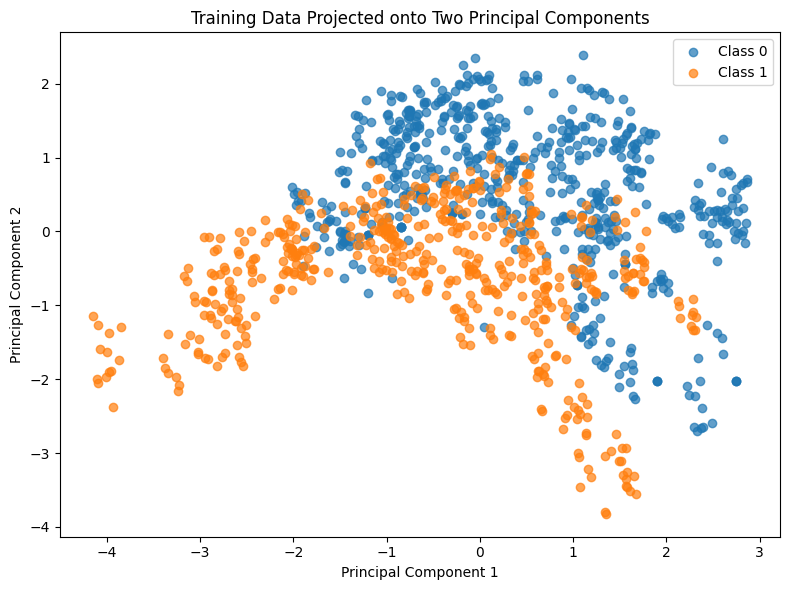

Explained variance: [0.5488 0.3188]


In [18]:
# ==========================================================
# 15. Visual 8: PCA projection of the scaled training data
# ==========================================================
# PCA is used only to visualise the four-dimensional data in two dimensions.

pca_for_view = PCA(n_components=2)
X_train_pca = pca_for_view.fit_transform(X_train)

plt.figure(figsize=(8, 6))

for label in (-1, 1):
    mask = y_train == label
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Class {0 if label == -1 else 1}",
        alpha=0.7,
    )

plt.title("Training Data Projected onto Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Explained variance:",
    np.round(pca_for_view.explained_variance_ratio_, 4),
)

This cell defines a `ManualPerceptron` class, providing a custom implementation of the Perceptron algorithm from scratch. It includes methods for:

*   **Initialization (`__init__`)**: Sets hyperparameters like learning rate, epochs, and random state.
*   **Activation function (`activation`)**: A static method that outputs +1 for scores >= 0 and -1 otherwise.
*   **Training (`fit`)**: Iterates through epochs, shuffles data (if `shuffle` is true), calculates predictions, updates weights and bias if misclassified, and implements the 'pocket' algorithm to keep track of the best-performing weights (those with the fewest errors).
*   **Decision function (`decision_function`)**: Calculates the linear score (`X @ weights + bias`).
*   **Prediction (`predict`)**: Applies the activation function to the decision scores to get class predictions.

In [19]:
# ==========================================================
# 16. Manual perceptron implementation
# ==========================================================

class ManualPerceptron:
    def __init__(
        self,
        learning_rate=0.01,
        epochs=100,
        shuffle=True,
        random_state=42,
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.shuffle = shuffle
        self.random_state = random_state

    @staticmethod
    def activation(score):
        return np.where(score >= 0, 1, -1)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        if set(np.unique(y)) - {-1, 1}:
            raise ValueError("The perceptron labels must be -1 or +1.")

        rng = np.random.default_rng(self.random_state)

        self.weights_ = np.zeros(X.shape[1], dtype=float)
        self.bias_ = 0.0

        self.errors_per_epoch_ = []
        self.weights_history_ = []
        self.bias_history_ = []

        self.best_errors_ = np.inf
        self.best_weights_ = self.weights_.copy()
        self.best_bias_ = self.bias_
        self.best_epoch_ = 0
        self.converged_ = False

        for epoch in range(self.epochs):
            indices = np.arange(X.shape[0])

            if self.shuffle:
                rng.shuffle(indices)

            errors = 0

            for index in indices:
                sample = X[index]
                target = y[index]

                score = np.dot(sample, self.weights_) + self.bias_
                prediction = 1 if score >= 0 else -1

                if prediction != target:
                    update = self.learning_rate * target
                    self.weights_ += update * sample
                    self.bias_ += update
                    errors += 1

            self.errors_per_epoch_.append(errors)
            self.weights_history_.append(self.weights_.copy())
            self.bias_history_.append(self.bias_)

            if errors < self.best_errors_:
                self.best_errors_ = errors
                self.best_weights_ = self.weights_.copy()
                self.best_bias_ = self.bias_
                self.best_epoch_ = epoch + 1

            if errors == 0:
                self.converged_ = True
                break

        self.weights_history_ = np.asarray(self.weights_history_)
        self.bias_history_ = np.asarray(self.bias_history_)

        return self

    def decision_function(self, X, use_pocket=False):
        X = np.asarray(X, dtype=float)

        if use_pocket:
            weights = self.best_weights_
            bias = self.best_bias_
        else:
            weights = self.weights_
            bias = self.bias_

        return X @ weights + bias

    def predict(self, X, use_pocket=False):
        scores = self.decision_function(X, use_pocket=use_pocket)
        return self.activation(scores)

This cell instantiates and trains the `ManualPerceptron` model using the scaled training data (`X_train`, `y_train`). It sets the learning rate, number of epochs, and ensures data shuffling. After training, it prints various statistics about the training process, including the number of epochs completed, whether the model converged (zero errors), the best training errors achieved (via the pocket algorithm), and the final and 'pocket' weights and bias. It also notes if convergence was not reached, suggesting non-separable data.

In [20]:
# ==========================================================
# 17. Train the manual perceptron
# ==========================================================

model = ManualPerceptron(
    learning_rate=0.01,
    epochs=100,
    shuffle=True,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)

print("Epochs completed       :", len(model.errors_per_epoch_))
print("Converged              :", model.converged_)
print("Best training errors   :", model.best_errors_)
print("Best epoch             :", model.best_epoch_)
print("Final weights          :", np.round(model.weights_, 4))
print("Final bias             :", round(model.bias_, 4))
print("Pocket weights         :", np.round(model.best_weights_, 4))
print("Pocket bias            :", round(model.best_bias_, 4))

if not model.converged_:
    print(
        "\nThe training errors did not reach zero. "
        "This is consistent with non-separable or noisy data."
    )

Epochs completed       : 100
Converged              : False
Best training errors   : 9
Best epoch             : 21
Final weights          : [-0.2832 -0.2968 -0.2746 -0.014 ]
Final bias             : -0.12
Pocket weights         : [-0.1638 -0.1722 -0.1663  0.0056]
Pocket bias            : -0.09

The training errors did not reach zero. This is consistent with non-separable or noisy data.


This cell visualizes the perceptron's learning progress by plotting the number of misclassifications on the training data against each epoch. It shows how the training errors change over time. A vertical dashed line indicates the epoch at which the 'pocket' algorithm found the minimum number of misclassifications, indicating the 'best' set of weights found during training.

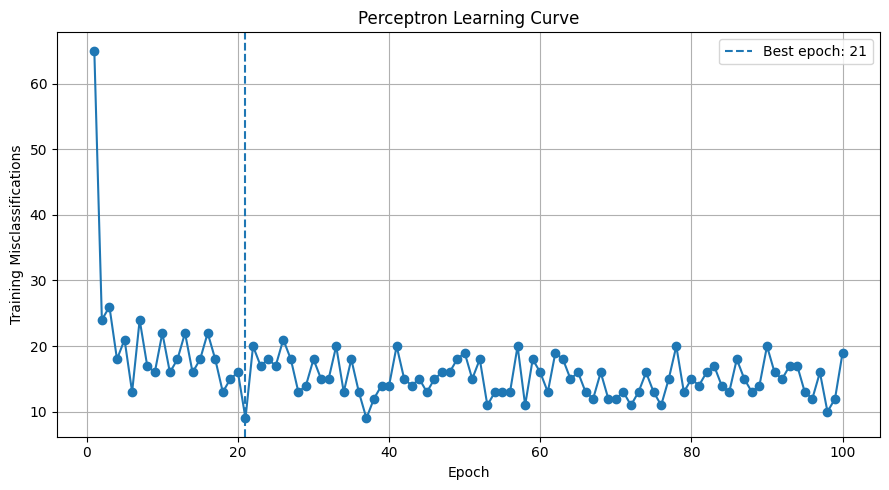

In [21]:
# ==========================================================
# 18. Visual 9: Misclassifications per epoch
# ==========================================================

epochs_completed = np.arange(1, len(model.errors_per_epoch_) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_completed,
    model.errors_per_epoch_,
    marker="o",
)
plt.axvline(
    model.best_epoch_,
    linestyle="--",
    label=f"Best epoch: {model.best_epoch_}",
)
plt.title("Perceptron Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Misclassifications")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

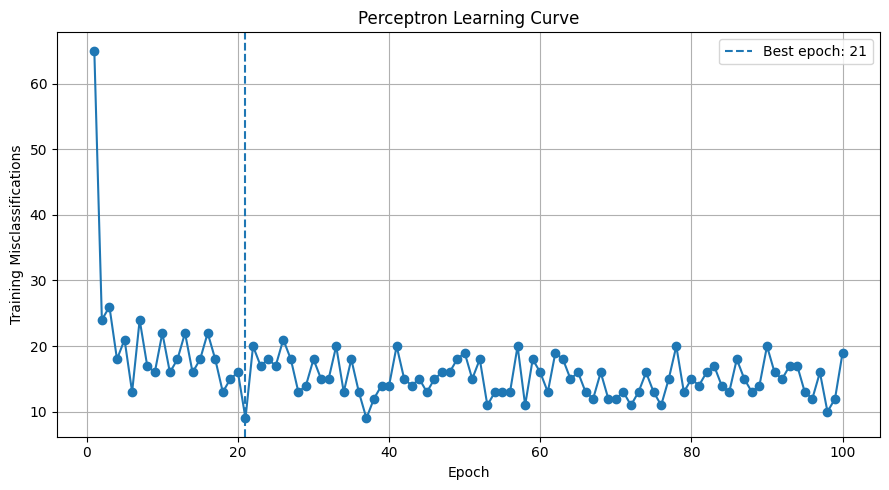

In [22]:
# ==========================================================
# 18. Visual 9: Misclassifications per epoch
# ==========================================================

epochs_completed = np.arange(1, len(model.errors_per_epoch_) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_completed,
    model.errors_per_epoch_,
    marker="o",
)
plt.axvline(
    model.best_epoch_,
    linestyle="--",
    label=f"Best epoch: {model.best_epoch_}",
)
plt.title("Perceptron Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Misclassifications")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This cell visualizes the evolution of the model's bias term over each training epoch. This plot helps to understand how the decision boundary's position (determined by the bias) adjusts during the learning process. A stable bias or a clear trend can offer insights into the model's convergence behavior.

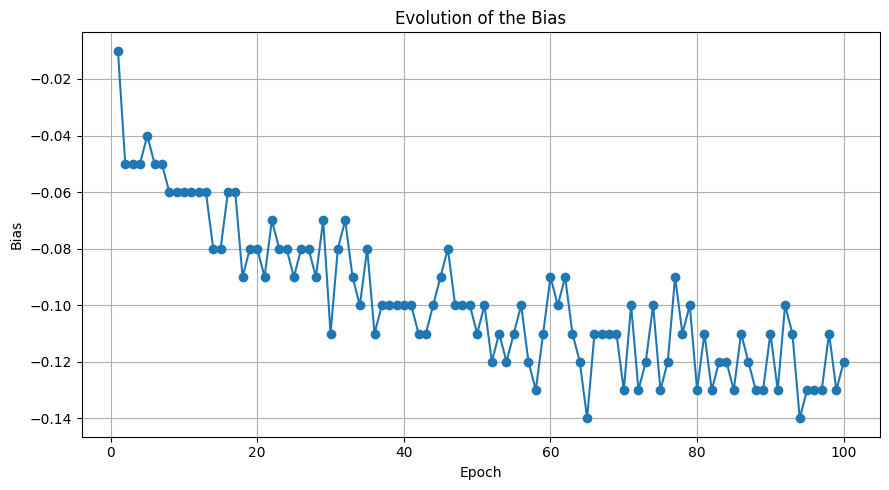

In [23]:
# ==========================================================
# 20. Visual 11: Bias trajectory
# ==========================================================

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_completed,
    model.bias_history_,
    marker="o",
)
plt.title("Evolution of the Bias")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)
plt.tight_layout()
plt.show()

This cell generates predictions on the unseen test dataset (`X_test`) using two different sets of learned parameters from the `ManualPerceptron`:

*   **`y_pred_pocket`**: Predictions using the 'pocket' weights and bias (which yielded the lowest training errors).
*   **`y_pred_final`**: Predictions using the weights and bias from the final epoch of training.

It then displays a preview of the first 15 predictions, comparing them against the actual test labels.

In [24]:
# ==========================================================
# 21. Generate test predictions
# ==========================================================

y_pred_pocket = model.predict(X_test, use_pocket=True)
y_pred_final = model.predict(X_test, use_pocket=False)

print("First 15 test predictions")
prediction_preview = pd.DataFrame({
    "Actual": y_test[:15],
    "Pocket prediction": y_pred_pocket[:15],
    "Final-epoch prediction": y_pred_final[:15],
})

print(prediction_preview.to_string(index=False))

First 15 test predictions
 Actual  Pocket prediction  Final-epoch prediction
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1
      1                  1                       1


This cell defines a `metric_summary` function to calculate common classification performance metrics: Accuracy, Precision, Recall, and F1-score. It then applies this function to both the 'pocket' model's predictions (`y_pred_pocket`) and the final-epoch model's predictions (`y_pred_final`) on the test set. The results are presented in a Pandas DataFrame for easy comparison, rounded to four decimal places.

In [25]:
# ==========================================================
# 22. Calculate classification metrics
# ==========================================================

def metric_summary(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
    }


pocket_metrics = metric_summary(y_test, y_pred_pocket)
final_metrics = metric_summary(y_test, y_pred_final)

metrics_table = pd.DataFrame({
    "Pocket model": pocket_metrics,
    "Final-epoch model": final_metrics,
}).T

print(metrics_table.round(4).to_string())

                   Accuracy  Precision  Recall      F1
Pocket model         0.9745     1.0000  0.9388  0.9684
Final-epoch model    0.9830     0.9896  0.9694  0.9794


This cell visualizes the calculated performance metrics (Accuracy, Precision, Recall, F1-score) for the 'pocket' perceptron model on the test set. A bar chart is used to display each metric's score, with values annotated on top of the bars, providing a quick overview of the model's performance.

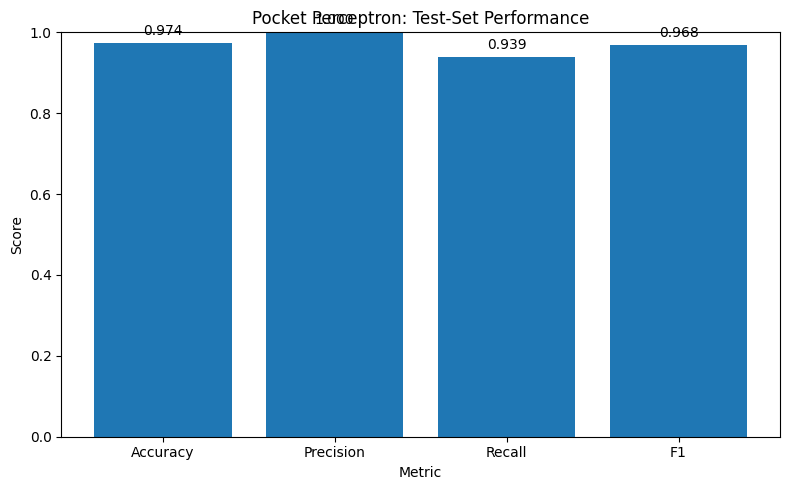

In [26]:
# ==========================================================
# 23. Visual 12: Performance metrics
# ==========================================================

metric_names = list(pocket_metrics.keys())
metric_values = list(pocket_metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.title("Pocket Perceptron: Test-Set Performance")
plt.xlabel("Metric")
plt.ylabel("Score")

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

This cell generates a comprehensive classification report for the 'pocket' perceptron model's predictions on the test set. The report includes precision, recall, f1-score, and support for each class, as well as overall accuracy and macro/weighted averages. This provides a detailed breakdown of the model's performance across different metrics and classes.

This cell visualizes the confusion matrix for the 'pocket' perceptron model's predictions on the test set. A confusion matrix shows the number of correct and incorrect predictions made by the classification model, broken down by each class. It helps to understand where the model is making errors (e.g., false positives, false negatives).

In [27]:
# ==========================================================
# 24. Classification report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred_pocket,
        labels=[-1, 1],
        target_names=["Class 0", "Class 1"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Class 0       0.96      1.00      0.98       137
     Class 1       1.00      0.94      0.97        98

    accuracy                           0.97       235
   macro avg       0.98      0.97      0.97       235
weighted avg       0.98      0.97      0.97       235



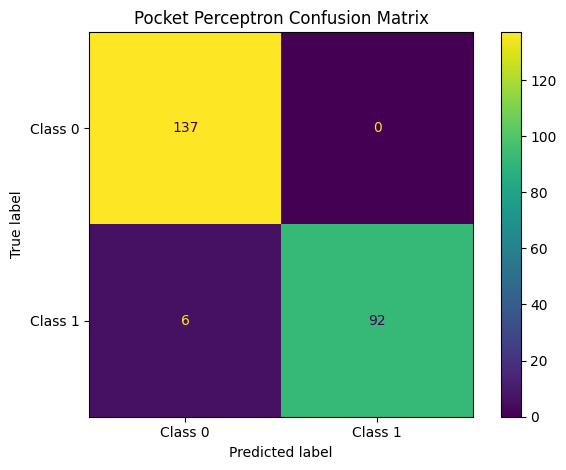

In [28]:
# ==========================================================
# 25. Visual 13: Confusion matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_pocket,
    labels=[-1, 1],
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"],
)

display.plot()
plt.title("Pocket Perceptron Confusion Matrix")
plt.tight_layout()
plt.show()

This cell visualizes the distribution of decision scores produced by the 'pocket' perceptron model for the test set. Decision scores represent the model's raw output before the activation function is applied. By plotting these scores separately for each actual class, you can see how well the model separates the classes based on its internal scoring. The vertical dashed line at 0 indicates the decision threshold where the model switches its prediction from -1 to +1.

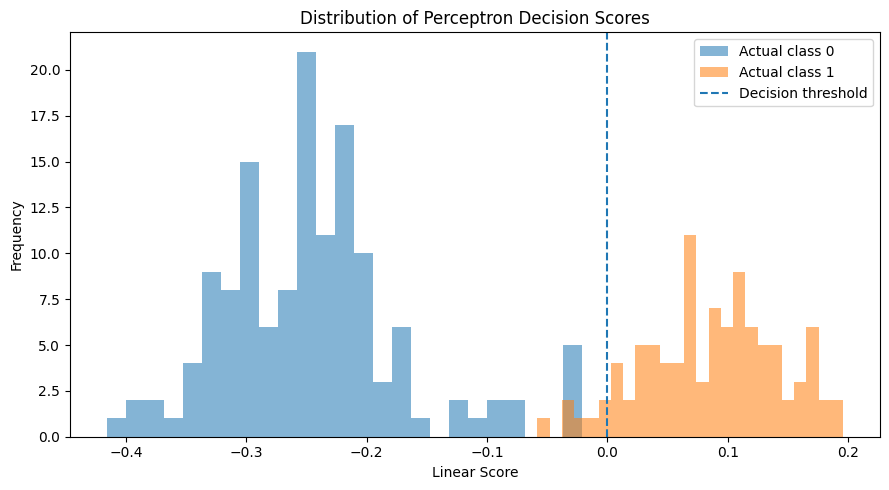

In [29]:
# ==========================================================
# 26. Visual 14: Decision-score distributions
# ==========================================================
# Distance from zero indicates the model's signed confidence,
# but it is not a calibrated probability.

test_scores = model.decision_function(
    X_test,
    use_pocket=True,
)

plt.figure(figsize=(9, 5))

for label in (-1, 1):
    plt.hist(
        test_scores[y_test == label],
        bins=25,
        alpha=0.55,
        label=f"Actual class {0 if label == -1 else 1}",
    )

plt.axvline(0, linestyle="--", label="Decision threshold")
plt.title("Distribution of Perceptron Decision Scores")
plt.xlabel("Linear Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

This cell identifies and displays the misclassified test observations made by the 'pocket' perceptron model. It creates a mask to find where the predicted label does not match the actual label. A DataFrame is then constructed to show the scaled feature values, actual class, predicted class, and the decision score for these misclassified instances. This helps in understanding the characteristics of the data points that the model struggles with.

In [30]:
# ==========================================================
# 27. Inspect misclassified test observations
# ==========================================================

misclassified_mask = y_pred_pocket != y_test
misclassified_indices = np.where(misclassified_mask)[0]

misclassified_table = pd.DataFrame(
    X_test[misclassified_mask],
    columns=[f"Scaled {name}" for name in feature_columns],
)

misclassified_table["Actual"] = y_test[misclassified_mask]
misclassified_table["Predicted"] = y_pred_pocket[misclassified_mask]
misclassified_table["Score"] = test_scores[misclassified_mask]

print("Number of misclassified test observations:", len(misclassified_table))
print(misclassified_table.head(15).round(4).to_string(index=False))

Number of misclassified test observations: 6
 Scaled variance  Scaled skewness  Scaled curtosis  Scaled entropy  Actual  Predicted   Score
         -1.5486          -2.6636           3.8526         -1.0226       1         -1 -0.0240
         -1.4598          -2.6568           3.8327         -0.7627       1         -1 -0.0350
         -1.3293          -2.7112           3.9118         -0.4063       1         -1 -0.0582
          0.4734           0.3086          -1.2797         -0.2572       1         -1 -0.0093
          0.5749          -0.0082          -1.0429          0.5677       1         -1 -0.0061
          0.7018           0.4597          -1.5107         -0.8209       1         -1 -0.0375


This cell prepares a two-dimensional PCA representation specifically for visualization purposes. It reduces the original 4-dimensional scaled data into 2 principal components for both the training and test sets. A new `ManualPerceptron` (`visual_model`) is then trained on this 2D training data to learn a simplified decision boundary that can be easily plotted. It prints whether this 2D model converged and its best training errors.

In [31]:
# ==========================================================
# 28. Prepare a two-dimensional PCA representation
# ==========================================================

pca_2d = PCA(n_components=2)

X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d = pca_2d.transform(X_test)

visual_model = ManualPerceptron(
    learning_rate=0.01,
    epochs=100,
    shuffle=True,
    random_state=RANDOM_STATE,
)

visual_model.fit(X_train_2d, y_train)

print("2D model converged:", visual_model.converged_)
print("2D best training errors:", visual_model.best_errors_)

2D model converged: False
2D best training errors: 297


This cell visualizes the decision regions of the 2D perceptron model in the PCA-transformed space. It creates a grid of points covering the range of the principal components and predicts their classes. The `contourf` function then shades these regions to show where the model predicts each class. The training data points are overlaid on this plot, allowing you to see how the model's decision boundary separates the classes in a simplified 2D view.

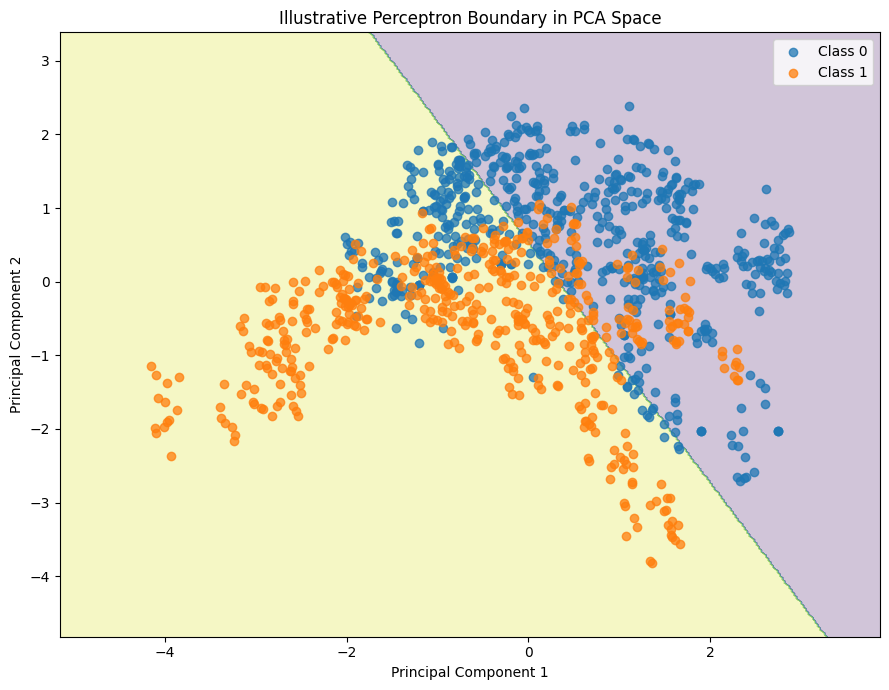

In [32]:
# ==========================================================
# 29. Visual 15: Two-dimensional decision regions
# ==========================================================

x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350),
)

grid_points = np.column_stack([
    grid_x.ravel(),
    grid_y.ravel(),
])

grid_predictions = visual_model.predict(
    grid_points,
    use_pocket=True,
).reshape(grid_x.shape)

plt.figure(figsize=(9, 7))
plt.contourf(
    grid_x,
    grid_y,
    grid_predictions,
    alpha=0.25,
)

for label in (-1, 1):
    mask = y_train == label
    plt.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        label=f"Class {0 if label == -1 else 1}",
        alpha=0.75,
    )

plt.title("Illustrative Perceptron Boundary in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

This cell visualizes the correct and incorrect predictions of the 2D perceptron model on the PCA-transformed test data. It scatters the test data points, marking correctly predicted points with one style and misclassified points with another (e.g., 'x'). This helps to visually assess the model's performance on unseen data in the simplified 2D space and identify where misclassifications occur relative to the decision boundary.

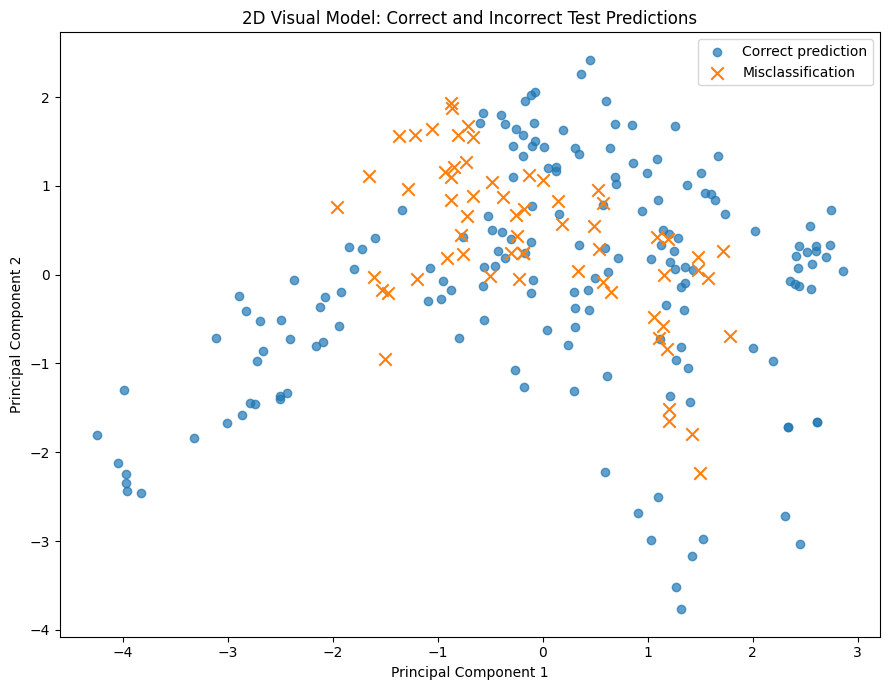

In [33]:
# ==========================================================
# 30. Visual 16: Correct and incorrect test predictions in PCA space
# ==========================================================

visual_test_predictions = visual_model.predict(
    X_test_2d,
    use_pocket=True,
)

correct_mask = visual_test_predictions == y_test

plt.figure(figsize=(9, 7))

plt.scatter(
    X_test_2d[correct_mask, 0],
    X_test_2d[correct_mask, 1],
    label="Correct prediction",
    alpha=0.7,
)

plt.scatter(
    X_test_2d[~correct_mask, 0],
    X_test_2d[~correct_mask, 1],
    marker="x",
    s=80,
    label="Misclassification",
)

plt.title("2D Visual Model: Correct and Incorrect Test Predictions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

This cell compares the performance of the manually implemented perceptron models (pocket and final-epoch) with scikit-learn's `Perceptron` implementation. It trains a `SklearnPerceptron` with similar parameters and then calculates its performance metrics on the test set. A Pandas DataFrame `comparison` is created to present the accuracy, precision, recall, and F1-score for all three models side-by-side, facilitating direct comparison.

In [34]:
# ==========================================================
# 31. Compare with scikit-learn's perceptron
# ==========================================================

sk_model = SklearnPerceptron(
    eta0=0.01,
    max_iter=100,
    tol=None,
    shuffle=True,
    random_state=RANDOM_STATE,
    fit_intercept=True,
)

sk_model.fit(X_train, y_train)
sk_predictions = sk_model.predict(X_test)

comparison = pd.DataFrame({
    "Manual pocket": pocket_metrics,
    "Manual final epoch": final_metrics,
    "scikit-learn": metric_summary(y_test, sk_predictions),
}).T

print(comparison.round(4).to_string())

                    Accuracy  Precision  Recall      F1
Manual pocket         0.9745     1.0000  0.9388  0.9684
Manual final epoch    0.9830     0.9896  0.9694  0.9794
scikit-learn          0.9830     1.0000  0.9592  0.9792


This cell visualizes the performance comparison across the three perceptron implementations (manual pocket, manual final epoch, and scikit-learn). A bar chart is used to display the Accuracy, Precision, Recall, and F1-score for each model, making it easy to compare their effectiveness on the test data.

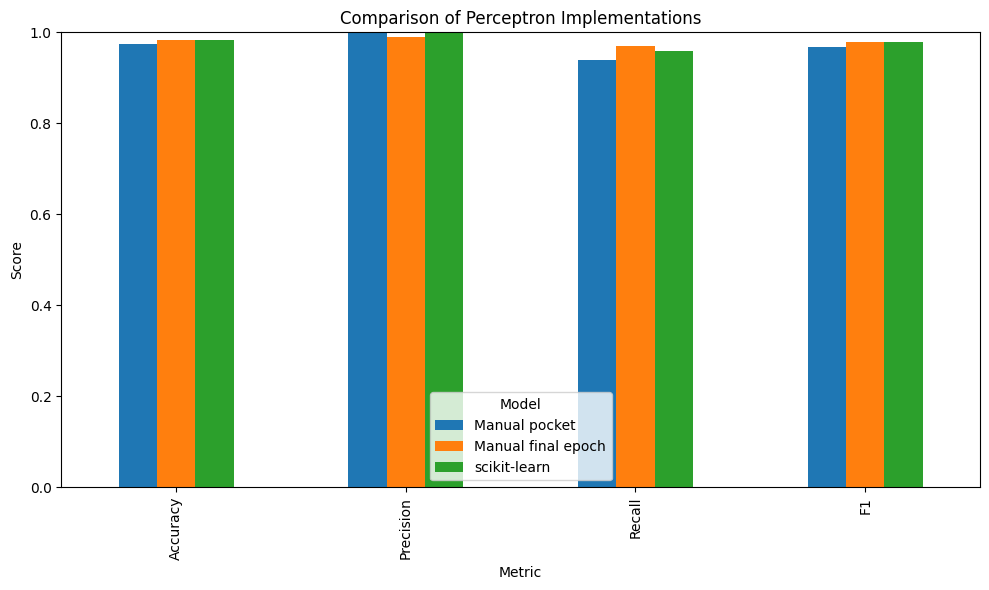

In [35]:
# ==========================================================
# 32. Visual 17: Model comparison
# ==========================================================

comparison.T.plot(kind="bar", figsize=(10, 6))
plt.ylim(0, 1)
plt.title("Comparison of Perceptron Implementations")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

This cell provides a reproducibility summary, printing key parameters and results from the entire notebook. It includes the random seed used, the number of training and test observations, the total epochs completed, whether the manual model converged, the best training error count, and the pocket-model's test accuracy. This summary helps to quickly grasp the experimental setup and main outcomes, ensuring reproducibility and easy reference.

In [36]:
# ==========================================================
# 33. Reproducibility summary
# ==========================================================

print("=" * 72)
print("PERCEPTRON MSc ASSESSED LAB COMPLETED")
print("=" * 72)
print("Random seed                 :", RANDOM_STATE)
print("Training observations       :", len(X_train))
print("Test observations           :", len(X_test))
print("Epochs completed            :", len(model.errors_per_epoch_))
print("Classical model converged    :", model.converged_)
print("Best training error count   :", model.best_errors_)
print("Pocket-model test accuracy  :", round(pocket_metrics["Accuracy"], 4))
print("=" * 72)

PERCEPTRON MSc ASSESSED LAB COMPLETED
Random seed                 : 42
Training observations       : 1137
Test observations           : 235
Epochs completed            : 100
Classical model converged    : False
Best training error count   : 9
Pocket-model test accuracy  : 0.9745
